# Fraud Detection — Model Training

Orchestrates the full pipeline:
`load → feature engineering → prep → split → SHAP selection → tune → train → evaluate → save`

All logic lives in `src/features.py`, `src/model.py`, and `src/ensemble.py`.
This notebook is for running and observing, not for defining functions.

In [1]:
import sys
sys.path.append('..')

import yaml
import mlflow
import mlflow.lightgbm
from pathlib import Path

import numpy as np
import pandas as pd

from src.features import (
    build_features,
    fit_freq_encoders, apply_freq_encoders,
)
from src.model import (
    prepare_features,
    three_way_split,
    select_features_shap,
    LABEL,
)
from src.ensemble import (
    encode_for_ensemble,
    tune_all,
    train_ensemble,
    evaluate_ensemble,
    predict_proba_ensemble,
    apply_calibrator,
    calibrate_ensemble,
    tune_threshold,
    save_ensemble,
)

DATA_DIR = '../data'
import src as _src
MLRUNS = str(Path(_src.__file__).parent.parent / 'mlruns')
mlflow.set_tracking_uri(MLRUNS)
mlflow.set_experiment('fraud-detection')

<Experiment: artifact_location='file:///Users/sonje/Desktop/Rohit/Old%20Desktop/Python/fraud-detection/mlruns/406551328193655437', creation_time=1779566767740, experiment_id='406551328193655437', last_update_time=1779566767740, lifecycle_stage='active', name='fraud-detection', tags={}>

In [2]:
with open('../config.yaml') as f:
    cfg = yaml.safe_load(f)

RANDOM_STATE = cfg['random_state']
np.random.seed(RANDOM_STATE)
print(f"RANDOM_STATE = {RANDOM_STATE}")

RANDOM_STATE = 42


In [3]:
QUICK_TEST  = cfg['tuning']['quick_test']
n_trials    = cfg['tuning']['n_trials_quick'] if QUICK_TEST else cfg['tuning']['n_trials']
shap_sample = 5_000                          if QUICK_TEST else cfg['feature_selection']['sample_size']

print(f'QUICK_TEST  = {QUICK_TEST}')
print(f'  n_trials    = {n_trials}')
print(f'  shap_sample = {shap_sample:,}')

QUICK_TEST  = True
  n_trials    = 3
  shap_sample = 5,000


## 1. Load raw data

In [4]:
trn = pd.read_csv(f'{DATA_DIR}/train_transaction.csv')
idn = pd.read_csv(f'{DATA_DIR}/train_identity.csv')
print(f'Transactions : {trn.shape}')
print(f'Identity     : {idn.shape}')

Transactions : (590540, 394)
Identity     : (144233, 41)


## 2. Feature engineering

In [5]:
df = build_features(trn, idn)
print(f'After feature engineering: {df.shape}')

Merged            : 590,540 rows × 434 cols
Identity coverage : 24.4%
Dropped 11 weak id columns


/Users/sonje/Desktop/Rohit/Old Desktop/Python/fraud-detection/.venv/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/sonje/Desktop/Rohit/Old Desktop/Python/fraud-detection/.venv/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/sonje/Desktop/Rohit/Old Desktop/Python/fraud-detection/.venv/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


After feature engineering: (590540, 464)


## 3. Prepare feature matrix

In [6]:
df = prepare_features(df)
print(f'After prep: {df.shape}')

Dropping 9 columns with >99% missing
Dropping 0 constant columns
After prep: (590540, 453)


## 4. Three-way chronological split

| Split | Fraction | Purpose |
|---|---|---|
| **train** | 70% | Model training + Optuna tuning |
| **cal** | 10% | Calibration only — never seen during training |
| **test** | 20% | Early stopping + final evaluation |

In [7]:
train_df, cal_df, test_df = three_way_split(
    df,
    train_frac=cfg['split']['train_frac'],
    cal_frac=cfg['split']['cal_frac'],
)

FEATURES = [c for c in train_df.columns if c != LABEL]
X_train, y_train = train_df[FEATURES], train_df[LABEL]
X_cal,   y_cal   = cal_df[FEATURES],   cal_df[LABEL]
X_test,  y_test  = test_df[FEATURES],  test_df[LABEL]

print(f'Train : {X_train.shape}  |  fraud rate: {y_train.mean():.2%}')
print(f'Cal   : {X_cal.shape}    |  fraud rate: {y_cal.mean():.2%}')
print(f'Test  : {X_test.shape}   |  fraud rate: {y_test.mean():.2%}')

# Persist engineered test set for the streaming simulation notebook
test_df.to_parquet('../data/test_features.parquet', index=False)
print(f"Saved {len(test_df):,} rows → data/test_features.parquet")

Train : (413378, 452)  |  fraud rate: 3.52%
Cal   : (59053, 452)    |  fraud rate: 3.49%
Test  : (118109, 452)   |  fraud rate: 3.44%
Saved 118,109 rows → data/test_features.parquet


## 4b. Frequency Encoding

Fit on **train only** — applied to cal and test using training-set counts to prevent leakage.

| Encoder | Columns | New features | Signal |
|---------|---------|-------------|--------|
| **Frequency** | card1, uid, P_emaildomain, addr1, DeviceInfo | `{col}_freq` | Rare entities → suspicious |

`uid` is dropped after encoding — `uid_freq` carries its signal without the high-cardinality problem.

> **Note on target encoding:** Dropped — `_te` features bake training labels into CV folds (leakage), inflating CV PR-AUC to ~0.78 while test collapses to 0.38.

In [8]:
# ── Frequency encoding ─────────────────────────────────────────────────────────
freq_encoders = fit_freq_encoders(X_train)
X_train = apply_freq_encoders(X_train, freq_encoders)
X_cal   = apply_freq_encoders(X_cal,   freq_encoders)
X_test  = apply_freq_encoders(X_test,  freq_encoders)

# Drop raw uid — uid_freq carries its signal without high-cardinality problems
for _df in [X_train, X_cal, X_test]:
    _df.drop(columns=["uid"], inplace=True, errors="ignore")

freq_cols = [c for c in X_train.columns if c.endswith("_freq")]
dt_cols   = [c for c in X_train.columns if c.startswith("dt_")]
print(f"Freq features      ({len(freq_cols)}) : {freq_cols}")
print(f"Time-delta features({len(dt_cols)}) : {dt_cols}")
print(f"Feature matrix     : {X_train.shape}")

Freq features      (5) : ['card1_freq', 'uid_freq', 'P_emaildomain_freq', 'addr1_freq', 'DeviceInfo_freq']
Time-delta features(2) : ['dt_card1_last', 'dt_uid_last']
Feature matrix     : (413378, 456)


## 5. Feature selection

Uses SHAP (TreeExplainer) on a 50K subsample to rank features by mean absolute
contribution, then keeps the top 40. Results are cached to `models/shap_features.json`
so SHAP only runs once — subsequent runs load from cache instantly.

In [9]:
X_train_f, X_test_f, X_cal_f, features_f = select_features_shap(
    X_train, y_train, X_test, X_cal=X_cal,
    top_n=cfg['feature_selection']['top_n'],
    sample_size=shap_sample,
    force_recompute=True,   # recompute — feature set changed with freq/target/time-delta features
)
print(f"\nSelected {len(features_f)} features from {X_train.shape[1]} total")

Computing SHAP on 5,000 rows × 456 features ...
SHAP selection : top 40 / 456 features
Top 10 by mean |SHAP|:
  TransactionDT                       0.2512
  C1                                  0.2429
  V61                                 0.2417
  card2                               0.2326
  V30                                 0.2276
  addr1                               0.2115
  dt_uid_last                         0.1899
  card1                               0.1814
  C14                                 0.1713
  card6                               0.1675
SHAP features cached to shap_features.json

Selected 40 features from 456 total


/Users/sonje/Desktop/Rohit/Old Desktop/Python/fraud-detection/.venv/lib/python3.9/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


## 6. Soft-voting ensemble (LightGBM + XGBoost + CatBoost)

Averages `predict_proba` across three independently tuned models.

### 6a. Encode categoricals

Ordinal-encodes category columns to integers. Fit on `X_train_f` so codes are
consistent across train and test splits.

In [10]:
X_train_enc, X_test_enc, cat_cols, cat_encoders = encode_for_ensemble(X_train_f, X_test_f)

# Apply same encoding to calibration set using training codes
X_cal_enc = X_cal_f.copy()
for col in cat_cols:
    X_cal_enc[col] = X_cal_enc[col].astype(object).map(cat_encoders[col]).fillna(-1).astype(int)

print(f"Encoded {len(cat_cols)} categorical columns: {cat_cols}")

Encoded 3 categorical columns: ['card6', 'M9', 'DeviceType']


### 6b. Tune all three models

Each model is tuned independently with Optuna.
`scale_pos_weight` / class weights are fixed from the class ratio — not searched.

In [11]:
all_best_params = tune_all(
    X_train_enc, y_train, cat_cols,
    n_trials=n_trials,   # 3 (QUICK_TEST) or 50 (full run)
)

print("\nBest params per model:")
for name, params in all_best_params.items():
    print(f"  {name}: {params}")

Tuning LightGBM  (3 trials) ...


  0%|          | 0/3 [00:00<?, ?it/s]

  LightGBM best PR-AUC : 0.4962  {'n_estimators': 250, 'max_depth': 12, 'learning_rate': 0.1205712628744377, 'bagging_fraction': 0.7993292420985183, 'feature_fraction': 0.5780093202212182}

Tuning XGBoost   (3 trials) ...


  0%|          | 0/3 [00:00<?, ?it/s]

  XGBoost  best PR-AUC : 0.5121  {'n_estimators': 444, 'max_depth': 9, 'learning_rate': 0.06300314164107554, 'subsample': 0.5145069122121801, 'colsample_bytree': 0.8668741481401414}

Tuning CatBoost  (3 trials) ...


  0%|          | 0/3 [00:00<?, ?it/s]

  CatBoost best PR-AUC : 0.4956  {'iterations': 485, 'depth': 6, 'learning_rate': 0.04282458384933268, 'subsample': 0.5567318505599852, 'colsample_bylevel': 0.608949434673262}

Best params per model:
  lgbm: {'n_estimators': 250, 'max_depth': 12, 'learning_rate': 0.1205712628744377, 'bagging_fraction': 0.7993292420985183, 'feature_fraction': 0.5780093202212182}
  xgb: {'n_estimators': 444, 'max_depth': 9, 'learning_rate': 0.06300314164107554, 'subsample': 0.5145069122121801, 'colsample_bytree': 0.8668741481401414}
  catboost: {'iterations': 485, 'depth': 6, 'learning_rate': 0.04282458384933268, 'subsample': 0.5567318505599852, 'colsample_bylevel': 0.608949434673262}


### 6c. Train, evaluate, and save ensemble

scale_pos_weight: 27.4  (neg=398,840, pos=14,538)

Training LightGBM ...
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
  Best iteration: 1

Training XGBoost ...

Training CatBoost ...
Ensemble PR-AUC  : 0.4502
Ensemble ROC-AUC : 0.8899


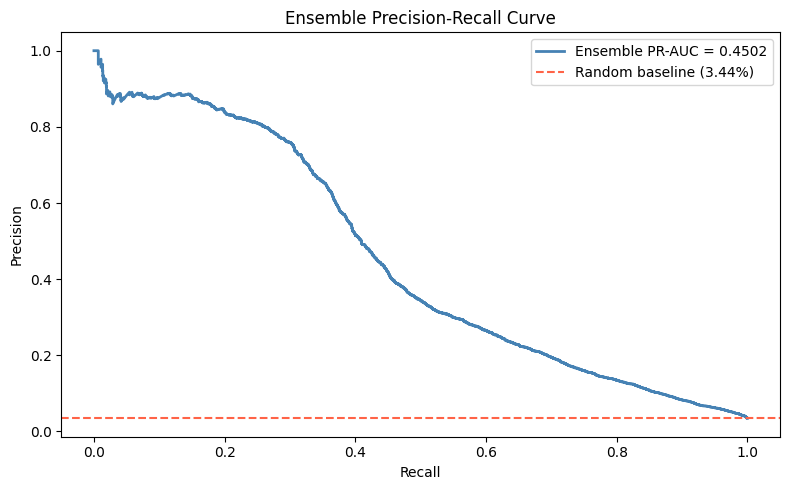

In [12]:
ensemble_models = train_ensemble(
    X_train_enc, y_train,
    X_test_enc,  y_test,
    best_params=all_best_params,
    cat_cols=cat_cols,
)

ensemble_metrics = evaluate_ensemble(
    ensemble_models, X_test_enc, y_test,
    threshold=cfg['ensemble']['threshold'],
    plot=True,
)

### 6d. Probability calibration

Boosted tree ensembles tend to produce overconfident scores (pushed toward 0 and 1).
Isotonic regression fits a monotone mapping from raw scores → calibrated probabilities
using the **calibration set** — data the models have never seen during training or early stopping.

Brier score  before calibration : 0.0441
Brier score  after  calibration : 0.0223  (sigmoid)


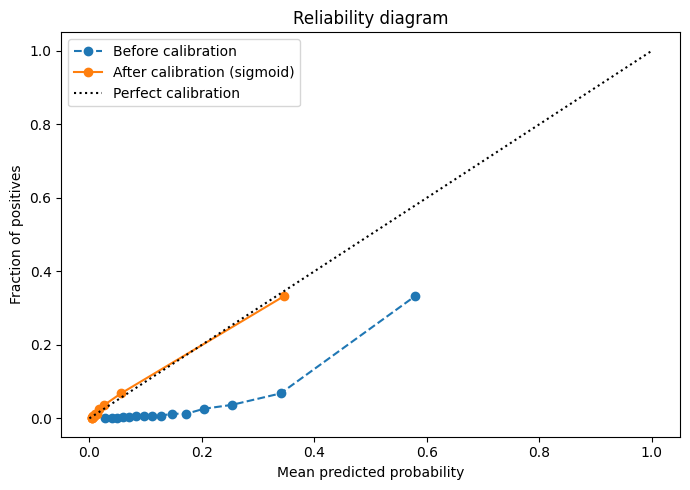

In [13]:
calibrator, cal_metrics = calibrate_ensemble(
    ensemble_models, X_cal_enc, y_cal,
    method=cfg['calibration']['method'],
)

### 6e. Threshold tuning

Find the decision threshold that maximises F-beta on the **test set** using calibrated probabilities.
β=2 weights recall 4× over precision — missing fraud costs more than a false alarm.

Optimal threshold (F2) : 0.0812
  Precision : 0.2583
  Recall    : 0.6102
  F2       : 0.4795


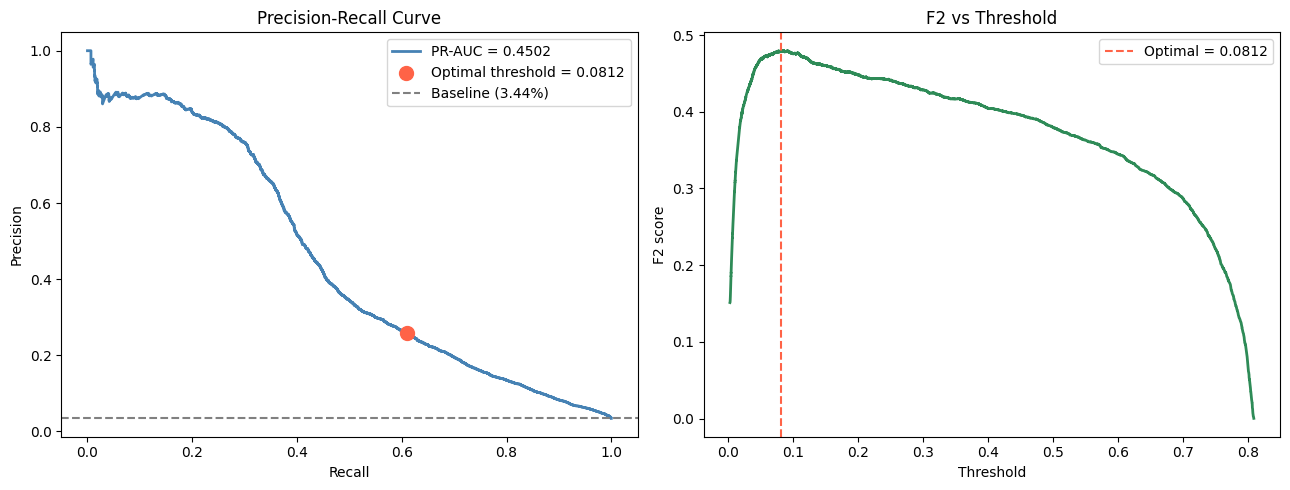

In [14]:
raw_probs_test = predict_proba_ensemble(ensemble_models, X_test_enc)
cal_probs_test = apply_calibrator(calibrator, raw_probs_test)

best = tune_threshold(y_test, cal_probs_test, beta=cfg['calibration']['beta'])

In [15]:
# Re-save ensemble with calibrator + optimal threshold baked in
save_ensemble(
    ensemble_models, cat_cols, cat_encoders,
    calibrator=calibrator,
    threshold=best['threshold'],
)

print(f"\nFinal model saved.")
print(f"  Calibration : {cfg['calibration']['method']}")
print(f"  Threshold   : {best['threshold']:.4f}  (F{cfg['calibration']['beta']:.0f}-optimal)")

Ensemble saved to /Users/sonje/Desktop/Rohit/Old Desktop/Python/fraud-detection/notebooks/../models/ensemble_fraud.pkl  (3 models, threshold=0.0812)

Final model saved.
  Calibration : sigmoid
  Threshold   : 0.0812  (F2-optimal)


## 7. MLflow logging

Logs all params, metrics, and artefact paths in one place so every run is
fully reproducible from the MLflow UI without hunting through individual cells.

In [16]:
beta = cfg['calibration']['beta']

with mlflow.start_run(run_name='ensemble-calibrated'):

    # ── Params ────────────────────────────────────────────────────────────────
    mlflow.log_params({
        'train_rows':          len(X_train_enc),
        'cal_rows':            len(X_cal_enc),
        'test_rows':           len(X_test_enc),
        'n_features':          X_train_enc.shape[1],
        'fraud_rate_train':    round(float(y_train.mean()), 4),
        'fraud_rate_cal':      round(float(y_cal.mean()), 4),
        'fraud_rate_test':     round(float(y_test.mean()), 4),
        'feature_selection':   'SHAP top 40',
        'ensemble':            'soft_vote_lgbm_xgb_catboost',
        'calibration_method':  cfg['calibration']['method'],
        'threshold_beta':      beta,
    })
    for model_name, params in all_best_params.items():
        mlflow.log_params({f"{model_name}__{k}": v for k, v in params.items()})

    # ── Metrics ───────────────────────────────────────────────────────────────
    mlflow.log_metrics({
        'pr_auc':                    ensemble_metrics['pr_auc'],
        'roc_auc':                   ensemble_metrics['roc_auc'],
        'brier_before_calibration':  cal_metrics['brier_before'],
        'brier_after_calibration':   cal_metrics['brier_after'],
        'optimal_threshold':         best['threshold'],
        'precision_at_threshold':    best['precision'],
        'recall_at_threshold':       best['recall'],
        f'f{beta:.0f}_at_threshold': best['f_beta'],
    })

    # ── Artefact ──────────────────────────────────────────────────────────────
    mlflow.log_artifact('../' + cfg['paths']['ensemble'])

    print(f"MLflow run logged.")
    print(f"  PR-AUC             : {ensemble_metrics['pr_auc']:.4f}")
    print(f"  Brier before / after: {cal_metrics['brier_before']:.4f} → {cal_metrics['brier_after']:.4f}")
    print(f"  Threshold (F{beta:.0f})   : {best['threshold']:.4f}  |  P={best['precision']:.3f}  R={best['recall']:.3f}")

MLflow run logged.
  PR-AUC             : 0.4502
  Brier before / after: 0.0441 → 0.0223
  Threshold (F2)   : 0.0812  |  P=0.258  R=0.610


## 8. View MLflow UI

```bash
mlflow ui
```
Open http://localhost:5000 to compare all runs side by side.